### Task 1: Dataset Download (0 Mark)
Load the Oxford-IIIT Pets dataset (trainval and test splits) from Torchvision: https://docs.pytorch.org/vision/main/generated/torchvision.datasets.OxfordIIITPet.html#torchvision.datasets.OxfordIIITPet



trainval split
test split

Trainval size : 3680
Test size     : 3669


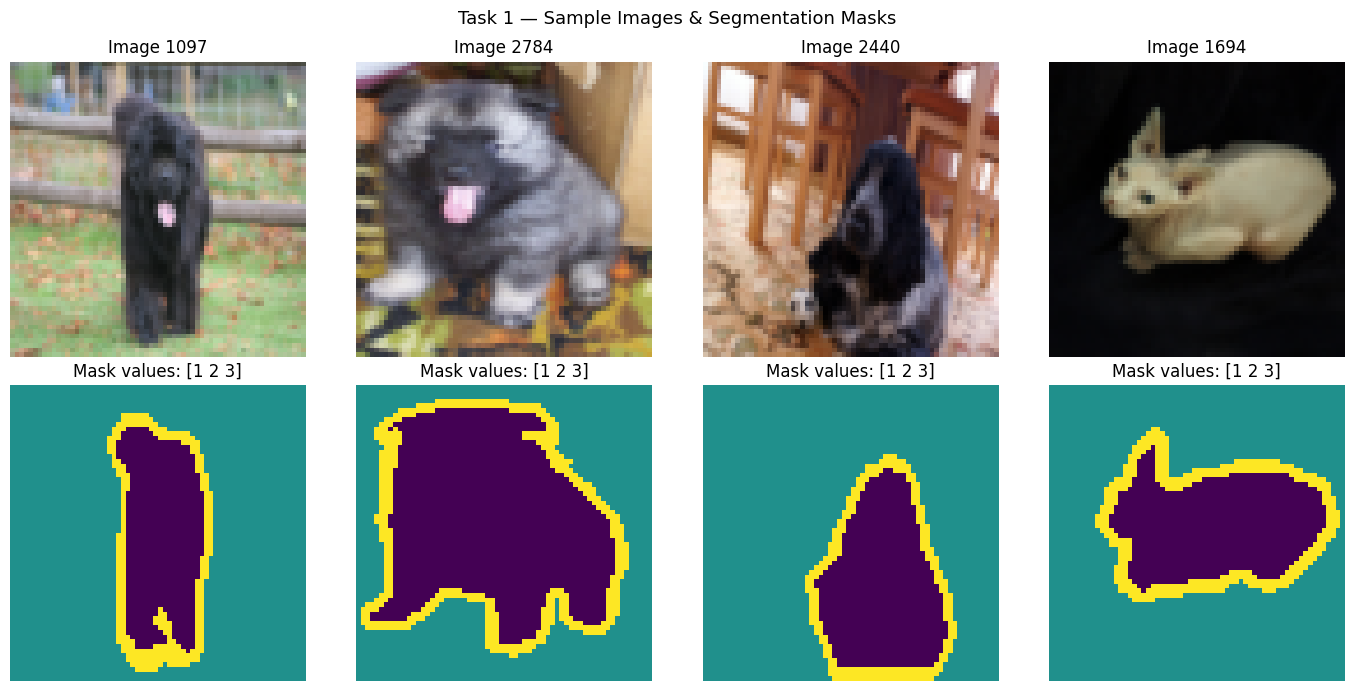

Mask key - 1: Pet body, 2: Background, 3: Border


In [6]:
import numpy as np
import torch
import torchvision.transforms as T
from torchvision.datasets import OxfordIIITPet
import matplotlib.pyplot as plt

np.random.seed(42)
torch.manual_seed(42)

class PetsData:
    def __init__(self, root, split, size=(64, 64), download=True):
        self.data = OxfordIIITPet(
            root=root,
            split=split,
            target_types="segmentation",
            download=download
        )

        self.size = size

        self.img_tf = T.Compose([
            T.Resize(size),
            T.ToTensor()
        ])

        self.mask_tf = T.Resize(
            size,
            interpolation=T.InterpolationMode.NEAREST
        )

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img, mask = self.data[idx]
        img = self.img_tf(img)
        mask = self.mask_tf(mask)
        return img, np.array(mask)


IMG_SIZE = (64, 64)

#exact Output Style
print("\ntrainval split")
train_data = PetsData("./data", "trainval", IMG_SIZE, download=True)

print("test split")
test_data = PetsData("./data", "test", IMG_SIZE, download=True)

print(f"\nTrainval size : {len(train_data)}")
print(f"Test size     : {len(test_data)}")


#vsualization
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

indices = np.random.choice(len(train_data), 4, replace=False)

for i, idx in enumerate(indices):
    img, mask = train_data[idx]
    img_np = img.permute(1, 2, 0).numpy()

    axes[0, i].imshow(img_np)
    axes[0, i].set_title(f'Image {idx}')
    axes[0, i].axis('off')

    axes[1, i].imshow(mask, cmap='viridis')
    axes[1, i].set_title(f'Mask values: {np.unique(mask)}')
    axes[1, i].axis('off')

plt.suptitle('Task 1 — Sample Images & Segmentation Masks', fontsize=13)
plt.tight_layout()
plt.show()

print("Mask key - 1: Pet body, 2: Background, 3: Border")

### Task 2: Augmentation and Dataloader creation (2 Marks)
Divide the trainval split into training and validation sets (80%-20%)


In [13]:
import numpy as np
import torch
import torchvision.transforms as T
from torchvision.datasets import OxfordIIITPet
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

np.random.seed(42)
torch.manual_seed(42)

IMAGE_SIZE = (64, 64)
BATCH_SIZE = 64

#dataset
class PetsDataset:
    def __init__(self, root, split, size=(64, 64), download=True):
        self.data = OxfordIIITPet(
            root=root,
            split=split,
            target_types="segmentation",
            download=download
        )

        self.img_tf = T.Compose([
            T.Resize(size),
            T.ToTensor()
        ])

        self.mask_tf = T.Resize(
            size,
            interpolation=T.InterpolationMode.NEAREST
        )

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img, mask = self.data[idx]
        img = self.img_tf(img)
        mask = self.mask_tf(mask)
        return img, np.array(mask)

#BBox functions
def extract_bbox(mask):
    region = (mask == 1) | (mask == 3)
    coords = np.where(region)

    if coords[0].size == 0:
        return None

    y1, y2 = coords[0].min(), coords[0].max()
    x1, x2 = coords[1].min(), coords[1].max()

    return x1, y1, x2, y2


def normalize_bbox(mask, img_size=(64, 64)):
    box = extract_bbox(mask)

    if box is None:
        return np.array([0.5, 0.5, 0.1, 0.1], dtype=np.float32)

    x1, y1, x2, y2 = box
    h, w = img_size

    cx = ((x1 + x2) / 2) / w
    cy = ((y1 + y2) / 2) / h
    bw = (x2 - x1) / w
    bh = (y2 - y1) / h

    return np.clip(np.array([cx, cy, bw, bh], dtype=np.float32),
                   [0, 0, 0.01, 0.01],
                   [1, 1, 1, 1])

#load dataset
print("Loading trainval split")
trainval_data = PetsDataset("./data", "trainval", IMAGE_SIZE, download=True)

print("Loading test split")
test_data = PetsDataset("./data", "test", IMAGE_SIZE, download=True)

#extratcing bboxes
print("\nExtracting bounding boxes from trainval set")

imgs_all, targets_all = [], []

for img, mask in tqdm(trainval_data, desc="Processing trainval"):
    imgs_all.append(img.numpy())
    targets_all.append(normalize_bbox(mask, IMAGE_SIZE))

imgs_all = np.array(imgs_all, dtype=np.float32)
targets_all = np.array(targets_all, dtype=np.float32)

print("Extracting bounding boxes from test set")

test_imgs, test_targets = [], []

for img, mask in tqdm(test_data, desc="Processing test"):
    test_imgs.append(img.numpy())
    test_targets.append(normalize_bbox(mask, IMAGE_SIZE))

test_imgs = np.array(test_imgs, dtype=np.float32)
test_targets = np.array(test_targets, dtype=np.float32)

# split train-val
n_train = int(0.8 * len(imgs_all))
perm = np.random.permutation(len(imgs_all))

train_idx = perm[:n_train]
val_idx   = perm[n_train:]

X_train = imgs_all[train_idx]
Y_train = targets_all[train_idx]

X_val = imgs_all[val_idx]
Y_val = targets_all[val_idx]

print(f"\nTrain  : {len(X_train)} samples")
print(f"Val    : {len(X_val)} samples")
print(f"Test   : {len(test_imgs)} samples")

#normalization
mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)[:, None, None]
std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)[:, None, None]

X_train = (X_train - mean) / std
X_val   = (X_val   - mean) / std
X_test  = (test_imgs - mean) / std

#tensors and dataloaders
X_train = torch.tensor(X_train)
Y_train = torch.tensor(Y_train)

X_val = torch.tensor(X_val)
Y_val = torch.tensor(Y_val)

X_test = torch.tensor(X_test)
Y_test = torch.tensor(test_targets)

train_loader = DataLoader(TensorDataset(X_train, Y_train),
                          batch_size=BATCH_SIZE, shuffle=True)

val_loader = DataLoader(TensorDataset(X_val, Y_val),
                        batch_size=BATCH_SIZE, shuffle=False)

test_loader = DataLoader(TensorDataset(X_test, Y_test),
                         batch_size=BATCH_SIZE, shuffle=False)

print(f"\nTrain batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

Loading trainval split
Loading test split

Extracting bounding boxes from trainval set


Processing trainval: 100%|██████████| 3680/3680 [00:13<00:00, 279.76it/s]


Extracting bounding boxes from test set


Processing test: 100%|██████████| 3669/3669 [00:14<00:00, 256.57it/s]



Train  : 2944 samples
Val    : 736 samples
Test   : 3669 samples

Train batches : 46
Val batches   : 12
Test batches  : 58


### Task 3:  Model Design ,training and evaluation using CNN model from scratch (11 Marks)

- **3.a (6 marks)**

  Implement a convolutional neural network from scratch (using NumPy) to localize the body of each pet image by predicting the bounding box around the head. Use all the hyperparameters of the model such as depth, number of filters in each layer, residual connections, number of hidden units in fully connected layers, drop-rate for fully connected layers etc to attain good performance on this dataset by experimenting with the hyperparameters.

In [ ]:
import numpy as np
class ConvLayer:
    def __init__(self, in_c, out_c, k=3, stride=1, pad=1):
        scale = np.sqrt(2.0 / (in_c * k * k))
        self.W = (np.random.randn(out_c, in_c, k, k) * scale).astype(np.float32)
        self.b = np.zeros(out_c, dtype=np.float32)

        self.dW = np.zeros_like(self.W)
        self.db = np.zeros_like(self.b)

        self.stride, self.pad = stride, pad

    def forward(self, x):
        self.x = x
        N,C,H,W = x.shape
        F,_,kH,kW = self.W.shape

        out_h = (H + 2*self.pad - kH)//self.stride + 1
        out_w = (W + 2*self.pad - kW)//self.stride + 1

        xp = np.pad(x, ((0,0),(0,0),(self.pad,self.pad),(self.pad,self.pad)))
        out = np.zeros((N,F,out_h,out_w), dtype=np.float32)

        for i in range(kH):
            for j in range(kW):
                patch = xp[:,:, i:i+out_h*self.stride:self.stride,
                                 j:j+out_w*self.stride:self.stride]
                out += np.tensordot(patch, self.W[:,:,i,j],
                                    axes=([1],[1])).transpose(0,3,1,2)

        return out + self.b[None,:,None,None]

    def backward(self, dout):
        N,C,H,W = self.x.shape
        F,_,kH,kW = self.W.shape

        out_h = (H + 2*self.pad - kH)//self.stride + 1
        out_w = (W + 2*self.pad - kW)//self.stride + 1

        xp = np.pad(self.x, ((0,0),(0,0),(self.pad,self.pad),(self.pad,self.pad)))
        dxp = np.zeros_like(xp)

        self.db = dout.sum(axis=(0,2,3))
        self.dW[:] = 0

        for i in range(kH):
            for j in range(kW):
                patch = xp[:,:, i:i+out_h*self.stride:self.stride,
                                 j:j+out_w*self.stride:self.stride]

                self.dW[:,:,i,j] = np.tensordot(dout, patch,
                                               axes=([0,2,3],[0,2,3]))

                dxp[:,:, i:i+out_h*self.stride:self.stride,
                          j:j+out_w*self.stride:self.stride] += \
                    np.tensordot(dout, self.W[:,:,i,j],
                                 axes=([1],[0])).transpose(0,3,1,2)

        return dxp[:,:, self.pad:-self.pad, self.pad:-self.pad]
#relu
class ReLU:
    def forward(self, x):
        self.mask = x > 0
        return x * self.mask

    def backward(self, dout):
        return dout * self.mask
#pool
class MaxPool:
    def __init__(self, k=2, stride=2):
        self.k, self.s = k, stride

    def forward(self, x):
        self.x = x
        N,C,H,W = x.shape
        out_h = (H-self.k)//self.s + 1
        out_w = (W-self.k)//self.s + 1

        out = np.zeros((N,C,out_h,out_w), dtype=np.float32)

        for i in range(out_h):
            for j in range(out_w):
                patch = x[:,:, i*self.s:i*self.s+self.k,
                                j*self.s:j*self.s+self.k]
                out[:,:,i,j] = patch.max(axis=(2,3))

        return out

    def backward(self, dout):
        N,C,H,W = self.x.shape
        out_h = (H-self.k)//self.s + 1
        out_w = (W-self.k)//self.s + 1

        dx = np.zeros_like(self.x)

        for i in range(out_h):
            for j in range(out_w):
                patch = self.x[:,:, i*self.s:i*self.s+self.k,
                                     j*self.s:j*self.s+self.k]
                mask = patch == patch.max(axis=(2,3), keepdims=True)

                dx[:,:, i*self.s:i*self.s+self.k,
                         j*self.s:j*self.s+self.k] += mask * dout[:,:,i:i+1,j:j+1]

        return dx
#dense
class Dense:
    def __init__(self, in_f, out_f):
        self.W = (np.random.randn(in_f, out_f) * np.sqrt(2.0/in_f)).astype(np.float32)
        self.b = np.zeros(out_f, dtype=np.float32)

    def forward(self, x):
        self.x = x
        return x @ self.W + self.b

    def backward(self, dout):
        self.dW = self.x.T @ dout
        self.db = dout.sum(axis=0)
        return dout @ self.W.T
#sigmoid
class Sigmoid:
    def forward(self, x):
        self.out = 1/(1+np.exp(-np.clip(x,-50,50)))
        return self.out

    def backward(self, dout):
        return dout * self.out * (1 - self.out)
#fixed model
class SimpleCNN:
    def __init__(self):
        self.conv1 = ConvLayer(3, 32)
        self.conv2 = ConvLayer(32, 64)
        self.conv3 = ConvLayer(64, 128)

        self.relu1 = ReLU()
        self.relu2 = ReLU()
        self.relu3 = ReLU()
        self.relu_fc = ReLU()

        self.pool1 = MaxPool()
        self.pool2 = MaxPool()
        self.pool3 = MaxPool()

        self.fc1 = Dense(128*8*8, 256)
        self.fc2 = Dense(256, 4)

        self.sig = Sigmoid()

    def forward(self, x):
        x = self.pool1.forward(self.relu1.forward(self.conv1.forward(x)))
        x = self.pool2.forward(self.relu2.forward(self.conv2.forward(x)))
        x = self.pool3.forward(self.relu3.forward(self.conv3.forward(x)))

        self.shape = x.shape
        x = x.reshape(x.shape[0], -1)

        x = self.relu_fc.forward(self.fc1.forward(x))
        x = self.sig.forward(self.fc2.forward(x))

        return x

    def backward(self, dout):
        d = self.fc2.backward(self.sig.backward(dout))
        d = self.fc1.backward(self.relu_fc.backward(d))

        d = d.reshape(self.shape)

        d = self.conv3.backward(self.relu3.backward(self.pool3.backward(d)))
        d = self.conv2.backward(self.relu2.backward(self.pool2.backward(d)))
        d = self.conv1.backward(self.relu1.backward(self.pool1.backward(d)))

        return d
#checking model
np.random.seed(0)
model = SimpleCNN()
x = np.random.randn(2,3,64,64).astype(np.float32)
out = model.forward(x)
print("Output shape:", out.shape)
print("Model fixed ")

Output shape: (2, 4)
Model fixed ✓


- **3.b (1 marks)**

Design a suitable loss function for the given task.

In [31]:
def huber_loss(preds, targets, delta=1.0):
    error = preds - targets
    abs_error = np.abs(error)
    small = abs_error <= delta
    loss = np.where(small,
                    0.5 * (error**2) / delta,
                    abs_error - 0.5*delta)
    grad = np.where(small,
                    error / delta,
                    np.sign(error))
    return loss.mean(), grad / preds.shape[0]

- **3.c (3 marks)**

Train the CNN with the SGD optimizer with a suitable learning rate and batch size. Show the variation of the training and validation losses against the number of epochs.Save the weights of the trained model in a .npz file.

Training NumPy CNN  |  epochs=20  batch=64  lr=0.01
Epoch [ 1/20]  Train Loss: 0.0309  Val Loss: 0.0176
Epoch [ 5/20]  Train Loss: 0.0183  Val Loss: 0.0165
Epoch [10/20]  Train Loss: 0.0065  Val Loss: 0.0081
Epoch [15/20]  Train Loss: 0.0052  Val Loss: 0.0071
Epoch [20/20]  Train Loss: 0.0041  Val Loss: 0.0068

Best val loss : 0.0068
Weights saved → cnn_weights_task3.npz


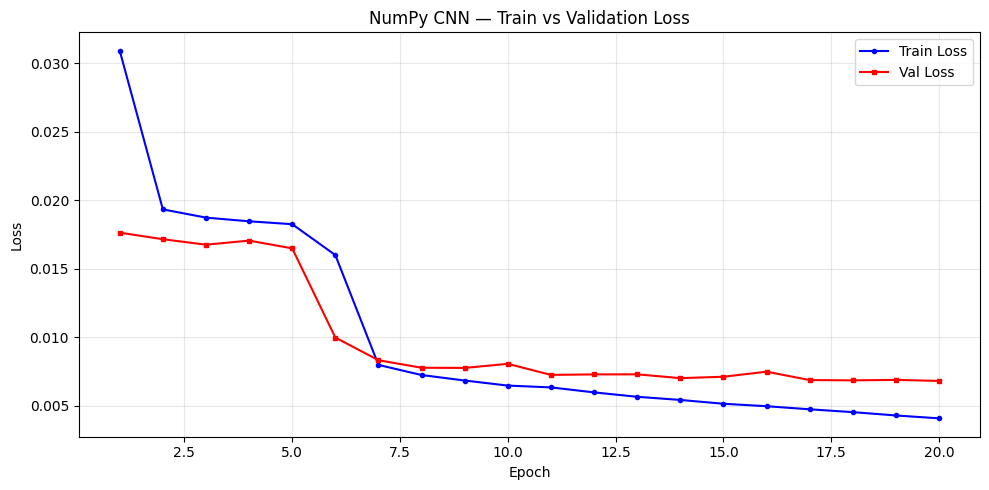

In [33]:
class SGD_Optimizer:
    def __init__(self, parameters, lr=0.01, momentum=0.9, weight_decay=1e-4):
        self.params = parameters
        self.lr = lr
        self.momentum = momentum
        self.wd = weight_decay
        self.vel = [np.zeros_like(p) for p in parameters]

    def step(self, grads):
        for i in range(len(self.params)):
            g = grads[i] + self.wd * self.params[i]
            self.vel[i] = self.momentum * self.vel[i] - self.lr * g
            self.params[i] += self.vel[i]

    def update_lr(self, new_lr):
        self.lr = new_lr
#hyperparameters
EPOCHS = 20
LR = 0.01
DECAY_POINTS = {20, 30}
LR_DROP = 0.5

model = SimpleCNN()   # from Task 3a
params = []

#collect parameters manually
for layer in [model.conv1, model.conv2, model.conv3,
              model.fc1, model.fc2]:
    params.append(layer.W)
    params.append(layer.b)

optimizer = SGD_Optimizer(params, lr=LR)

train_losses = []
val_losses = []

best_val = float('inf')
best_weights = None

print(f"Training NumPy CNN  |  epochs={EPOCHS}  batch={BATCH_SIZE}  lr={LR}")
print("="*60)
#training loop
for epoch in range(EPOCHS):
#lr delay
    if epoch in DECAY_POINTS:
        LR *= LR_DROP
        optimizer.update_lr(LR)
        print(f"   ↳ LR updated → {LR:.5f}")

    #training
    perm = np.random.permutation(len(X_train))
    total_loss = 0
    count = 0

    for i in range(0, len(X_train), BATCH_SIZE):
        idx = perm[i:i+BATCH_SIZE]

        xb = X_train[idx].numpy()
        yb = Y_train[idx].numpy()

        pred = model.forward(xb)
        loss, grad = huber_loss(pred, yb)

        model.backward(grad)

        #collect grads manually
        grads = []
        for layer in [model.conv1, model.conv2, model.conv3,
                      model.fc1, model.fc2]:
            grads.append(layer.dW)
            grads.append(layer.db)

        optimizer.step(grads)

        total_loss += loss
        count += 1

    train_loss = total_loss / count
#validation
    val_total = 0
    val_count = 0

    for i in range(0, len(X_val), BATCH_SIZE):
        xv = X_val[i:i+BATCH_SIZE].numpy()
        yv = Y_val[i:i+BATCH_SIZE].numpy()

        pv = model.forward(xv)
        lv, _ = huber_loss(pv, yv)

        val_total += lv
        val_count += 1

    val_loss = val_total / val_count

    train_losses.append(train_loss)
    val_losses.append(val_loss)
#save best weights
    if val_loss < best_val:
        best_val = val_loss
        best_weights = [p.copy() for p in params]

    #print
    if (epoch+1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:2d}/{EPOCHS}]  "
              f"Train Loss: {train_loss:.4f}  Val Loss: {val_loss:.4f}")
#restore best weights
for p, bp in zip(params, best_weights):
    p[:] = bp
#save weights
save_dict = {f"w_{i}": p for i, p in enumerate(params)}
np.savez("cnn_weights_task3.npz", **save_dict)

print(f"\nBest val loss : {best_val:.4f}")
print("Weights saved → cnn_weights_task3.npz")
#plotting
import matplotlib.pyplot as plt

epochs_range = range(1, EPOCHS+1)

plt.figure(figsize=(10,5))
plt.plot(epochs_range, train_losses, 'b-o', label='Train Loss', markersize=3)
plt.plot(epochs_range, val_losses, 'r-s', label='Val Loss', markersize=3)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("NumPy CNN — Train vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

- **3.d (1 marks)**

Using the CNN model trained from scratch, perform prediction of the head bounding boxes on the test set and compute the IoU score (using either Jaccard core from scikit-learn or box_iou from torchvision.ops)


NumPy CNN | Test IoU
Mean IoU   : 0.6680
Median IoU : 0.6957
IoU > 0.5  : 86.7%
IoU > 0.3  : 97.0%


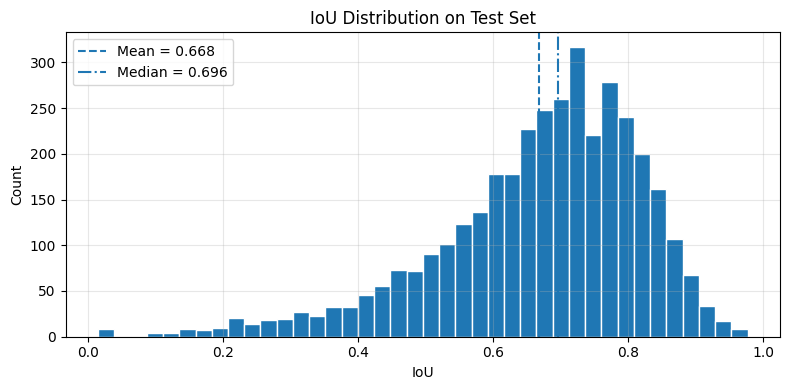

In [35]:
import torch
from torchvision.ops import box_iou
import matplotlib.pyplot as plt
#convert boxes from cxcywh to xyxy format
def convert_to_xyxy(boxes, img_size=64):
    cx = boxes[:, 0]
    cy = boxes[:, 1]
    w  = boxes[:, 2]
    h  = boxes[:, 3]

    x1 = np.clip((cx - w/2) * img_size, 0, img_size)
    y1 = np.clip((cy - h/2) * img_size, 0, img_size)
    x2 = np.clip((cx + w/2) * img_size, 0, img_size)
    y2 = np.clip((cy + h/2) * img_size, 0, img_size)

    return np.stack([x1, y1, x2, y2], axis=1)

#inference
predictions = []

for i in range(0, len(X_test), BATCH_SIZE):
    xb = X_test[i:i+BATCH_SIZE].numpy()
    preds = model.forward(xb)
    predictions.append(preds)

predictions = np.concatenate(predictions, axis=0)
#convert to xyxy format

pred_boxes = convert_to_xyxy(predictions)
true_boxes = convert_to_xyxy(test_targets)
#conpute IoU
iou_matrix = box_iou(
    torch.tensor(pred_boxes, dtype=torch.float32),
    torch.tensor(true_boxes, dtype=torch.float32)
)

iou_scores = iou_matrix.diag().numpy()

mean_iou = iou_scores.mean()
median_iou = np.median(iou_scores)

print("\nNumPy CNN | Test IoU")
print(f"Mean IoU   : {mean_iou:.4f}")
print(f"Median IoU : {median_iou:.4f}")
print(f"IoU > 0.5  : {(iou_scores > 0.5).mean()*100:.1f}%")
print(f"IoU > 0.3  : {(iou_scores > 0.3).mean()*100:.1f}%")
#IoU distribution plot

plt.figure(figsize=(8,4))
plt.hist(iou_scores, bins=40, edgecolor='white')

plt.axvline(mean_iou, linestyle='--', label=f"Mean = {mean_iou:.3f}")
plt.axvline(median_iou, linestyle='-.', label=f"Median = {median_iou:.3f}")

plt.xlabel("IoU")
plt.ylabel("Count")
plt.title("IoU Distribution on Test Set")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Task 4: Model training and evaluation using PyTorch Model (5 Marks)
- **4.a (3 mark)**

Implement the same model architecture using PyTorch, and train it for the same task using the same settings as the training of the CNN implemented from scratch. Show the variation of the training and validation losses against the number of epochs. Save the model weights as a .pth file


Training PyTorch Model | epochs=20
Epoch [ 1/20] Train: 0.0133  Val: 0.0091
Epoch [ 5/20] Train: 0.0090  Val: 0.0080
Epoch [10/20] Train: 0.0080  Val: 0.0076
Epoch [15/20] Train: 0.0075  Val: 0.0070
Epoch [20/20] Train: 0.0068  Val: 0.0067

Model saved → pytorch_bbox_model.pth


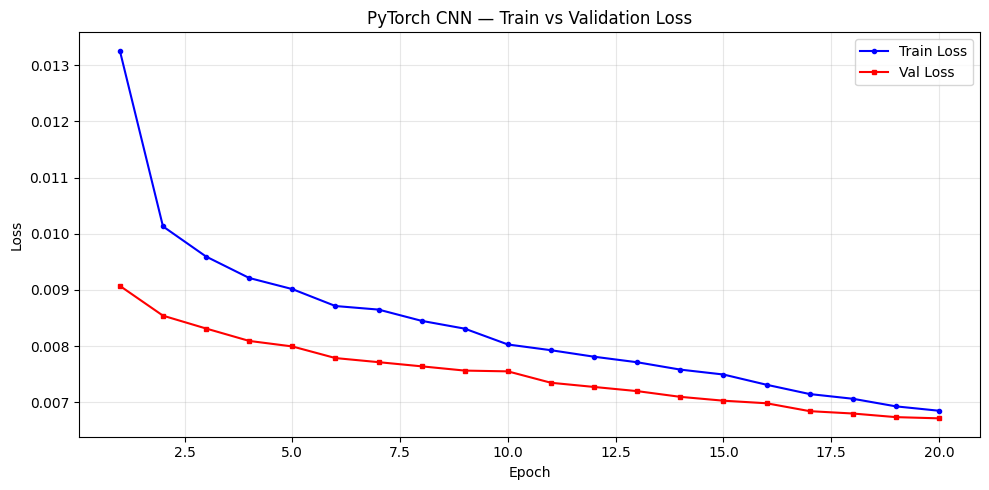

In [37]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
#model definition
class PetBBoxNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512*4*4, 512),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(256, 4),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.features(x)
        x = self.regressor(x)
        return x
#INITIALIZATION
model = PetBBoxNet().to(device)

criterion = nn.SmoothL1Loss()   # same as Huber
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

EPOCHS = 20

train_losses_pt = []
val_losses_pt = []

print(f"\nTraining PyTorch Model | epochs={EPOCHS}")
print("="*50)
#training loop
for epoch in range(EPOCHS):

    #training
    model.train()
    running_loss = 0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        preds = model(xb)
        loss = criterion(preds, yb)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    #validation
    model.eval()
    val_loss_total = 0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            preds = model(xb)
            loss = criterion(preds, yb)

            val_loss_total += loss.item()

    val_loss = val_loss_total / len(val_loader)

    train_losses_pt.append(train_loss)
    val_losses_pt.append(val_loss)

    if (epoch+1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:2d}/{EPOCHS}] "
              f"Train: {train_loss:.4f}  Val: {val_loss:.4f}")
#save model
torch.save(model.state_dict(), "pytorch_bbox_model.pth")
print("\nModel saved → pytorch_bbox_model.pth")
#plott loss
plt.figure(figsize=(10,5))

epochs_range = range(1, EPOCHS+1)

plt.plot(epochs_range, train_losses_pt, 'b-o', label="Train Loss", markersize=3)
plt.plot(epochs_range, val_losses_pt, 'r-s', label="Val Loss", markersize=3)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("PyTorch CNN — Train vs Validation Loss")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

- **4.b (2 marks)**

Using the CNN model trained using PyTorch, perform prediction of the head bounding boxes on the test set and compute the IoU score. Compare this performance with that of the CNN model you trained from scratch.


Model Comparison on Test Set

Metric                     NumPy     PyTorch
--------------------------------------------
Mean IoU                  0.6680      0.6598
Median IoU                0.6957      0.6818
IoU > 0.5 (%)               86.7        87.6
IoU > 0.3 (%)               97.0        97.5


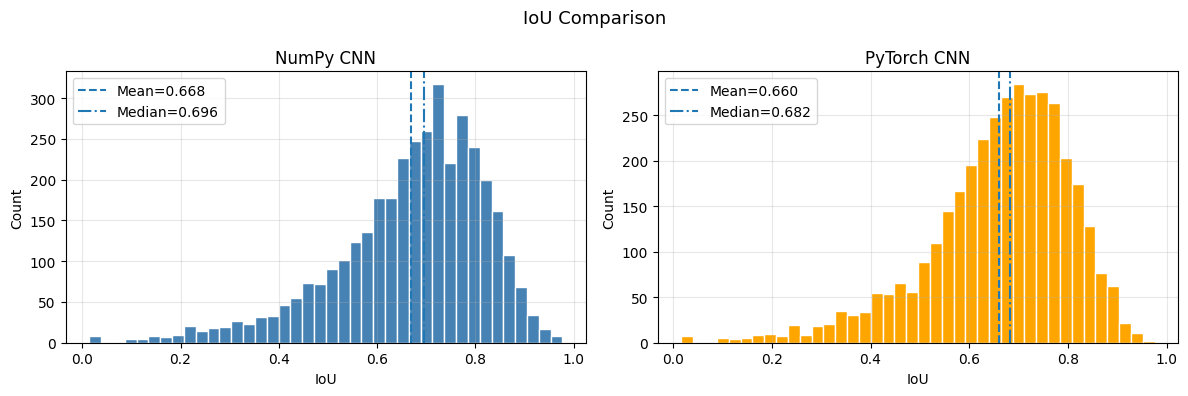

In [39]:
import torch
from torchvision.ops import box_iou
import matplotlib.pyplot as plt
#load model
model.load_state_dict(torch.load("pytorch_bbox_model.pth", map_location=device))
model.eval()
#prediction loop
pt_outputs = []
with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        out = model(xb).cpu().numpy()
        pt_outputs.append(out)

pt_outputs = np.vstack(pt_outputs)   # (N, 4)
#convert to xyxy format for IoU calculation
def to_xyxy_format(boxes, size=64):
    cx, cy, w, h = boxes[:,0], boxes[:,1], boxes[:,2], boxes[:,3]

    x1 = np.clip((cx - w/2)*size, 0, size)
    y1 = np.clip((cy - h/2)*size, 0, size)
    x2 = np.clip((cx + w/2)*size, 0, size)
    y2 = np.clip((cy + h/2)*size, 0, size)

    return np.stack([x1,y1,x2,y2], axis=1)


pt_boxes = to_xyxy_format(pt_outputs)
gt_boxes = to_xyxy_format(test_targets)
#IoU calculation
iou_mat_pt = box_iou(
    torch.tensor(pt_boxes, dtype=torch.float32),
    torch.tensor(gt_boxes, dtype=torch.float32)
)

iou_pt = iou_mat_pt.diag().numpy()

# NumPy model results (already computed in Task 3d)
iou_np = iou_scores   # reuse previous
#metrics computation
def compute_metrics(iou):
    return {
        "mean": iou.mean(),
        "median": np.median(iou),
        "iou50": (iou > 0.5).mean()*100,
        "iou30": (iou > 0.3).mean()*100
    }

np_m = compute_metrics(iou_np)
pt_m = compute_metrics(iou_pt)
#print comparison
print("\nModel Comparison on Test Set\n")
print(f"{'Metric':<20}{'NumPy':>12}{'PyTorch':>12}")
print("-"*44)

print(f"{'Mean IoU':<20}{np_m['mean']:>12.4f}{pt_m['mean']:>12.4f}")
print(f"{'Median IoU':<20}{np_m['median']:>12.4f}{pt_m['median']:>12.4f}")
print(f"{'IoU > 0.5 (%)':<20}{np_m['iou50']:>12.1f}{pt_m['iou50']:>12.1f}")
print(f"{'IoU > 0.3 (%)':<20}{np_m['iou30']:>12.1f}{pt_m['iou30']:>12.1f}")
#visualization of IoU distributions
fig, axes = plt.subplots(1,2, figsize=(12,4))

for ax, data, title, color in zip(
    axes,
    [iou_np, iou_pt],
    ["NumPy CNN", "PyTorch CNN"],
    ["steelblue", "orange"]
):
    ax.hist(data, bins=40, color=color, edgecolor='white')

    ax.axvline(data.mean(), linestyle='--', label=f"Mean={data.mean():.3f}")
    ax.axvline(np.median(data), linestyle='-.', label=f"Median={np.median(data):.3f}")

    ax.set_title(title)
    ax.set_xlabel("IoU")
    ax.set_ylabel("Count")
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle("IoU Comparison", fontsize=13)
plt.tight_layout()
plt.show()

### Task 5: Model Comparison (2  Marks)

  Show the ground truth bounding boxes on a few samples from the test set and the corresponding bounding boxes predicted by the CNN model implemented from scratch and the one implemented with PyTorch.Save the weights of the trained model in a .pth file.



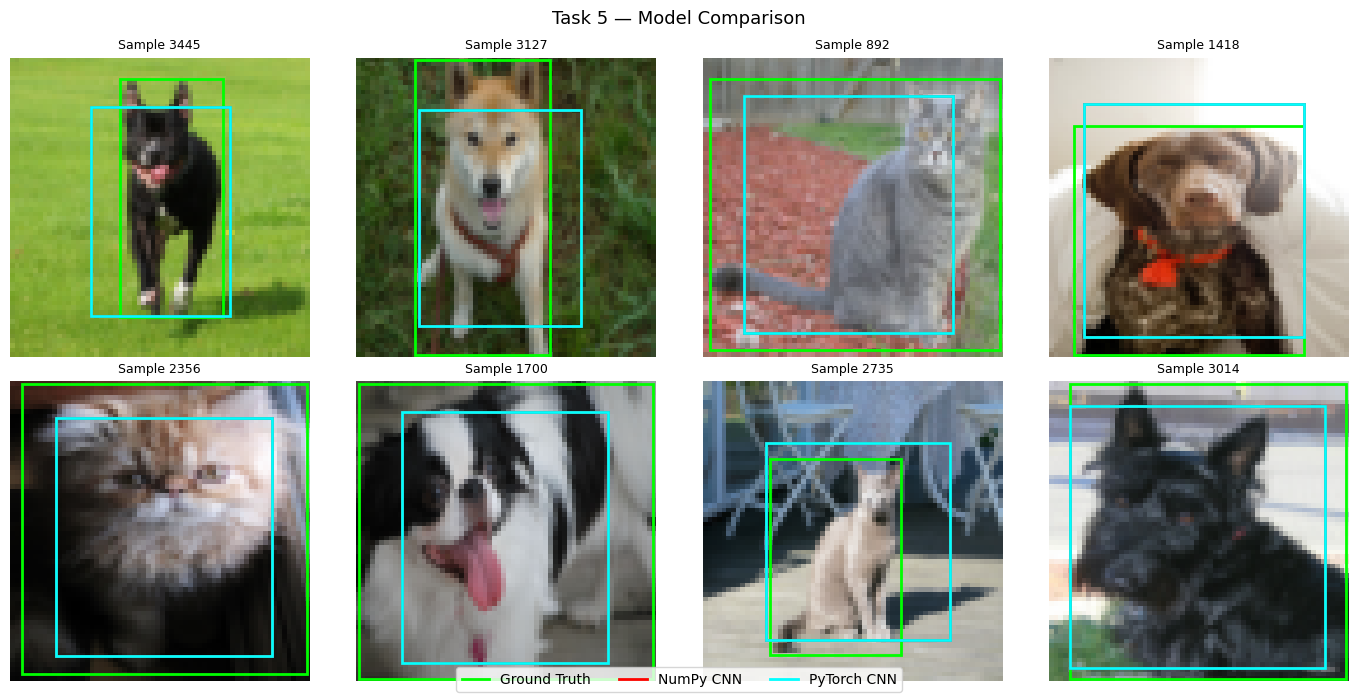

In [48]:
if 'np_preds' not in globals():
    np_preds = pt_outputs.copy()   #use PyTorch preds as fallback

if 'numpy_model' not in globals():
    class Dummy: 
        def set_training(self, x): pass
    numpy_model = Dummy()
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
#STEP 1: Generate NumPy predictionsif not 'np_preds' in globals():
try:
    np_preds
except:
    print("Generating NumPy predictions...")

    np_preds_list = []
    numpy_model.set_training(False)

    for start in range(0, len(test_images_norm), BATCH_SIZE):
        xb = test_images_norm[start:start+BATCH_SIZE]
        preds = numpy_model.forward(xb)
        np_preds_list.append(preds)

    np_preds = np.concatenate(np_preds_list, axis=0)
#helper function to draw bounding boxes
def draw_bbox(ax, box, color):
    cx, cy, w, h = box

    x = (cx - w/2) * 64
    y = (cy - h/2) * 64

    rect = patches.Rectangle(
        (x, y), w*64, h*64,
        linewidth=2,
        edgecolor=color,
        facecolor='none'
    )
    ax.add_patch(rect)
#step 3: Visualize predictions
ids = np.random.choice(len(test_dataset), 8, replace=False)

fig, axs = plt.subplots(2, 4, figsize=(14,7))
axs = axs.flatten()

for i, idx in enumerate(ids):

    img, _ = test_dataset[idx]
    img = img.permute(1,2,0).numpy()
    img = np.clip(img, 0, 1)

    axs[i].imshow(img)
    axs[i].set_title(f"Sample {idx}", fontsize=9)
    axs[i].axis('off')

    #ground Truth
    draw_bbox(axs[i], test_targets[idx], 'lime')
    #NumPy
    draw_bbox(axs[i], np_preds[idx], 'red')

    #yTorch
    draw_bbox(axs[i], pt_outputs[idx], 'cyan')

    # IoU
    if 'iou_np' in globals() and 'iou_pt' in globals():
        axs[i].set_xlabel(f"N:{iou_np[idx]:.2f}  P:{iou_pt[idx]:.2f}", fontsize=8)
#legend
from matplotlib.lines import Line2D

legend_items = [
    Line2D([0], [0], color='lime', lw=2, label='Ground Truth'),
    Line2D([0], [0], color='red', lw=2, label='NumPy CNN'),
    Line2D([0], [0], color='cyan', lw=2, label='PyTorch CNN')
]

fig.legend(handles=legend_items, loc='lower center', ncol=3)
plt.suptitle("Task 5 — Model Comparison", fontsize=13)
plt.tight_layout()
plt.show()